In [1]:
file_read = "001_refit"
file_write = "003_coefs"

In [2]:
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"
n_features_min = 11

In [3]:
import polars as pl

df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [4]:
df_coefs

n_features,alpha,2_zero,3_zero,4_zero,6_zero,7_zero,9_zero,12_zero,14_zero,16_zero,18_zero,19_zero,21_zero,46_zero,68_zero,91_zero,148_zero,157_zero,161_zero,232_zero,234_zero,235_zero,237_zero,240_zero,247_zero,252_zero,255_zero,270_zero,271_zero,275_zero,293_zero,324_zero,327_zero,355_zero,357_zero,415_zero,442_zero,465_zero,469_zero,494_zero,505_zero,506_zero,507_zero,519_zero,538_zero,540_zero,543_zero,575_zero,597_zero,602_zero,605_zero,642_zero
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
51,18.66,-0.067979,-0.013893,-0.05099,0.094306,0.137459,-0.180594,0.067959,0.040716,0.048933,-0.041322,0.067821,-0.002005,0.013773,0.064027,-0.0963,-0.052697,-0.171512,0.03306,-0.228158,0.121697,0.006431,-0.004823,-0.079436,0.004388,0.005083,-0.002265,-0.056083,0.125576,-0.014757,-0.004528,-0.11216,-0.02449,-0.05612,-0.032595,-0.053056,0.024551,-0.107753,-0.095389,0.105537,-0.005958,-0.169737,0.073299,0.024662,-0.00081,0.077066,0.201163,0.009707,-0.14577,-0.042926,-0.016307,-0.004822
50,17.97,-0.067712,-0.014648,-0.050403,0.093692,0.139769,-0.181913,0.068243,0.040497,0.048129,-0.040495,0.067279,-0.001722,0.014398,0.063716,-0.098408,-0.052764,-0.174204,0.033774,-0.23057,0.122689,0.008392,-0.005267,-0.080659,0.004167,0.004854,-0.00174,-0.055899,0.127778,-0.013971,-0.004048,-0.113555,-0.027111,-0.055937,-0.032001,-0.052571,0.024611,-0.107848,-0.09667,0.107147,-0.005349,-0.171485,0.073663,0.024785,null,0.076696,0.205363,0.010048,-0.146726,-0.042897,-0.017215,-0.004549
49,17.28,-0.067275,-0.015436,-0.049623,0.093062,0.142252,-0.183113,0.068289,0.040217,0.047284,-0.039495,0.066686,null,0.015046,0.063415,-0.100863,-0.053069,-0.177022,0.034376,-0.23302,0.123831,0.010104,-0.005808,-0.081989,0.003915,0.004536,-0.00114,-0.055607,0.130138,-0.013255,-0.003493,-0.115146,-0.029824,-0.055646,-0.031325,-0.052133,0.024717,-0.107895,-0.098052,0.108686,-0.00467,-0.173283,0.07413,0.025026,null,0.07653,0.209753,0.010436,-0.147938,-0.042601,-0.018,-0.004014
48,16.26,-0.066821,-0.01668,-0.048636,0.091953,0.146172,-0.18523,0.068678,0.039824,0.045932,-0.037969,0.065739,null,0.016169,0.062915,-0.104373,-0.053032,-0.181457,0.035522,-0.23687,0.125568,0.01355,-0.006531,-0.083973,0.003473,0.004149,null,-0.055264,0.133932,-0.011856,-0.002575,-0.117507,-0.034027,-0.055303,-0.030223,-0.051263,0.024875,-0.107887,-0.100082,0.111369,-0.00355,-0.176115,0.074709,0.025285,null,0.075791,0.216638,0.010917,-0.149416,-0.042499,-0.019471,-0.003298
47,15.08,-0.066185,-0.018304,-0.047327,0.09046,0.151192,-0.187754,0.069136,0.039352,0.044204,-0.03596,0.064501,null,0.017604,0.062297,-0.108846,-0.052945,-0.187045,0.036869,-0.24158,0.127828,0.018041,-0.007434,-0.086502,0.002781,0.003651,null,-0.054845,0.138787,-0.009997,null,-0.120539,-0.039209,-0.054885,-0.028735,-0.050186,0.025086,-0.107744,-0.102671,0.114739,-0.002082,-0.17965,0.075408,0.025611,null,0.074761,0.225216,0.011479,-0.151241,-0.042302,-0.021392,-0.002355
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
9,1.0,null,null,null,null,0.535389,null,null,null,null,null,null,null,null,null,-0.294856,null,null,null,null,0.408724,0.538366,null,-1.119903,null,null,null,null,1.087761,null,null,-0.805174,null,null,null,null,null,null,-0.442204,null,null,null,null,null,null,null,0.392132,null,null,null,null,null
8,2.57,null,null,null,null,0.591863,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.452002,0.224045,null,-0.692318,null,null,null,null,0.797403,null,null,-0.749482,null,null,null,null,null,null,-0.57328,null,null,null,null,null,null,null,0.230773,null,null,null,null,null
7,0.84,null,null,null,null,0.427202,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.373027,null,null,-0.76765,null,null,null,null,1.153528,null,null,-0.460988,null,null,null,null,null,null,-0.796

In [5]:
columns_feat = [column for column in df_coefs.columns if "zero" in column]

In [6]:
data = df_coefs[columns_feat].to_numpy()

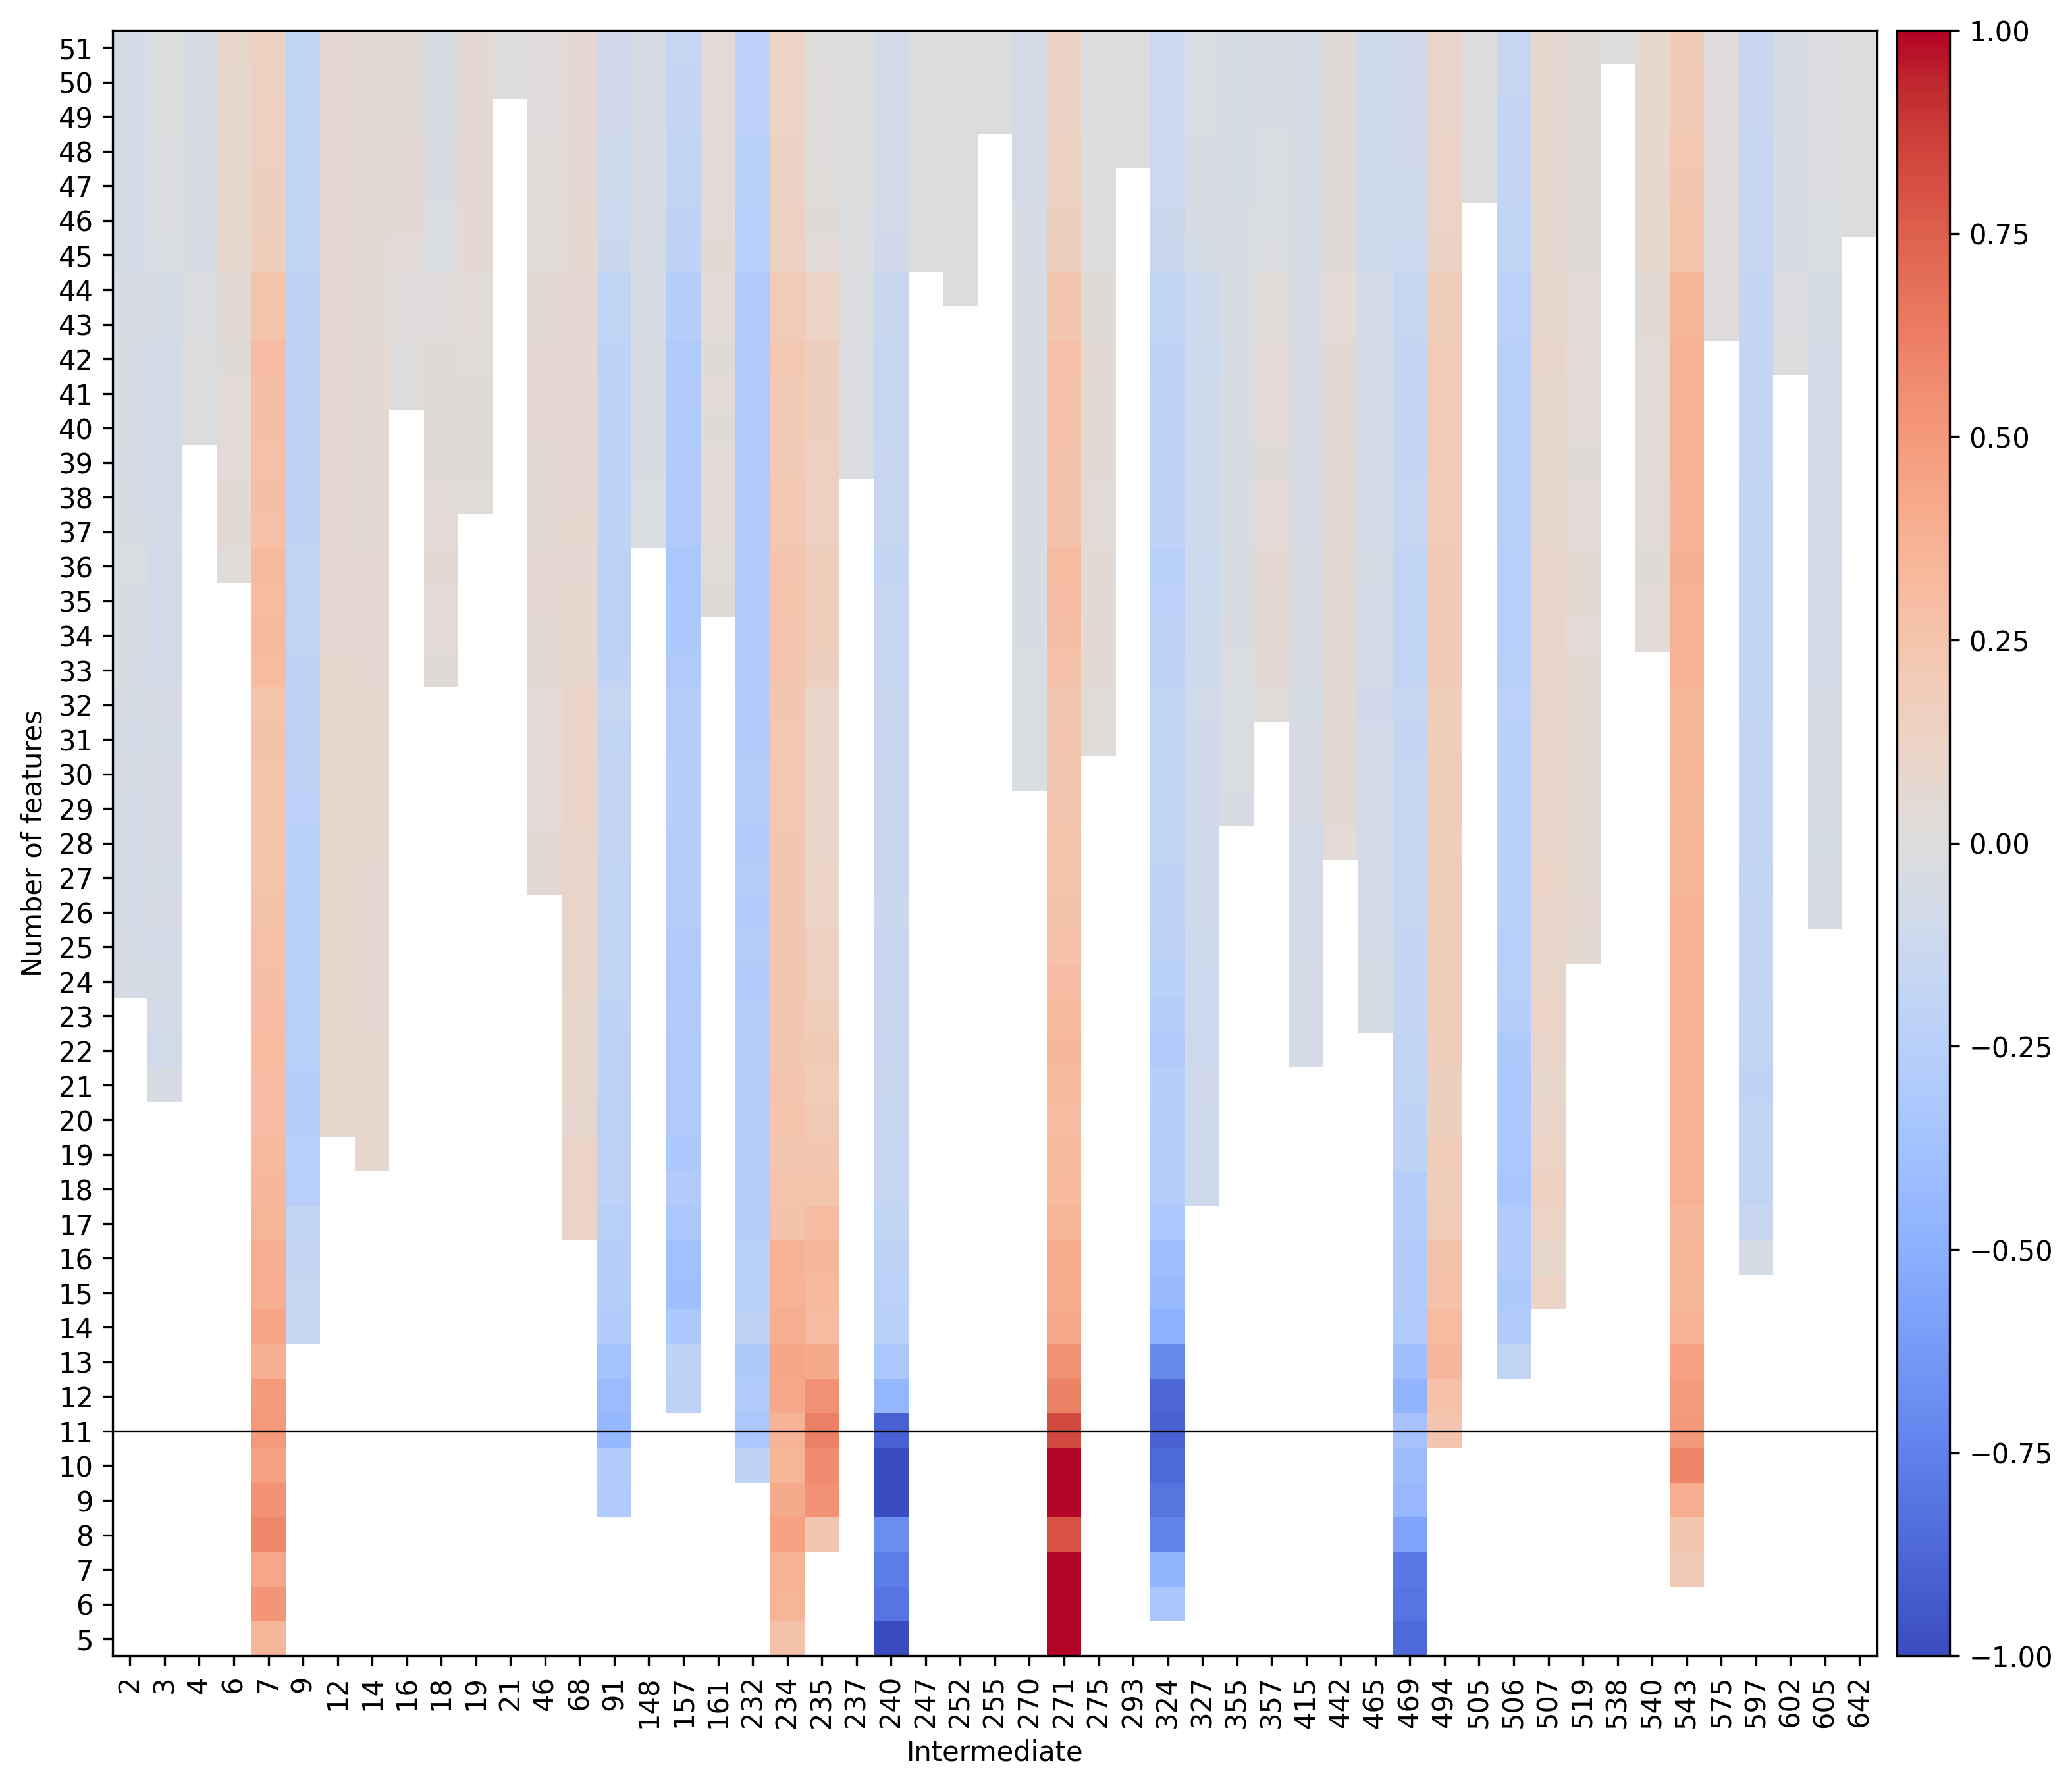

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

im = ax.imshow(data, vmin=-1, vmax=1, cmap="coolwarm")
cax = make_axes_locatable(ax).append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)
ax.axhline(data.shape[1] - n_features_min, c="black", lw=0.8)

ax.set_xlabel("Intermediate")
ax.set_ylabel("Number of features")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.set_yticklabels(df_coefs["n_features"])

plt.savefig(
    f"{file_write}_imshow.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [8]:
data_coef_min = (
    df_coefs
    .filter(pl.col("n_features") == n_features_min)
    .select(columns_feat)
    .to_numpy()
    .ravel()
)

In [9]:
data_coef_min = np.nan_to_num(data_coef_min, nan=0.0)

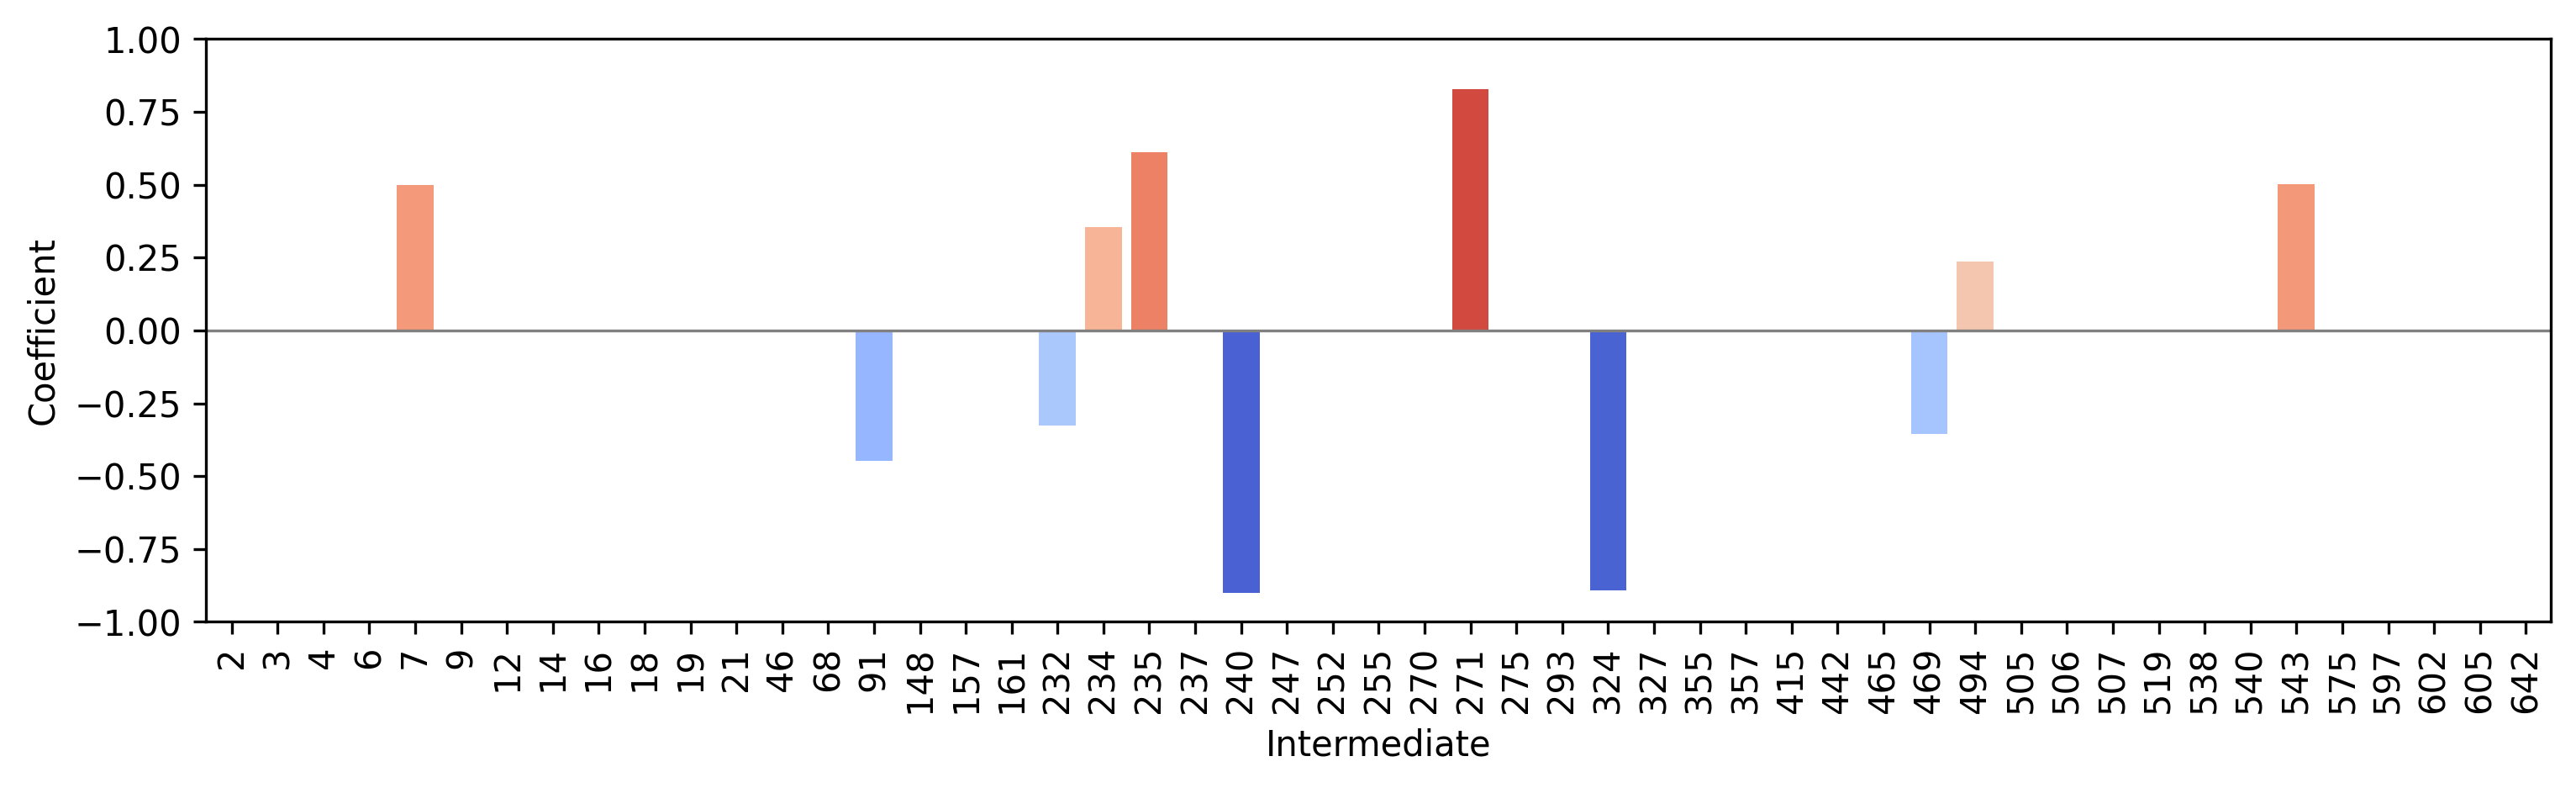

In [10]:
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 3), dpi=300)

norm = mcolors.TwoSlopeNorm(vcenter=0.0, vmin=-1.0, vmax=1.0)
colors = plt.cm.coolwarm(norm(data_coef_min))
ax.bar(
    np.arange(len(data_coef_min)),
    data_coef_min,
    color=colors
)
ax.axhline(0, c="gray", lw=0.8)

ax.set_xlabel("Intermediate")
ax.set_ylabel("Coefficient")
ax.set_xticks(np.arange(len(data_coef_min)))
ax.set_xticklabels([c[:-5] for c in columns_feat], rotation=90)
ax.margins(x=0.003)
ax.set_ylim(-1.0, 1.0)

plt.savefig(
    f"{file_write}_bar.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()